# LightGBM - Air Pollution Forecasting

https://www.kaggle.com/datasets/rupakroy/lstm-datasets-multivariate-univariate?select=LSTM-Multivariate_pollution.csv

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from lightgbm import LGBMRegressor
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
import optuna

In [3]:
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.simplefilter('ignore', ValueWarning)

In [4]:
raw = pd.read_csv('data/Multivariate_pollution.csv') # Extract data

raw['date'] = pd.to_datetime(raw['date'])            # Convert 'date' column to datetime format
raw.set_index('date', inplace=True)                  # Set 'date' as index
raw_numeric = raw.select_dtypes(include='number')    # Select only numeric columns

df = raw_numeric.resample('D').mean()                # Aggregate by day (take daily mean)

df.head() 

,pollution,dew,temp,press,wnd_spd,snow,rain
date,,,,,,,
2010-01-02,145.958333,-8.500000,-5.125000,1024.750000,24.860000,0.708333,0.0
2010-01-03,78.833333,-10.125000,-8.541667,1022.791667,70.937917,14.166667,0.0
2010-01-04,31.333333,-20.875000,-11.500000,1029.291667,111.160833,0.000000,0.0
2010-01-05,42.458333,-24.583333,-14.458333,1033.625000,56.920000,0.000000,0.0
2010-01-06,56.416667,-23.708333,-12.541667,1033.750000,18.511667,0.000000,0.0


In [5]:
# Select features and target
features = ["dew", "temp", "press", "snow", "rain"]
target = "pollution"

# Drop missing values
df = df[features + [target]].dropna()

df.head()

,dew,temp,press,snow,rain,pollution
date,,,,,,
2010-01-02,-8.500000,-5.125000,1024.750000,0.708333,0.0,145.958333
2010-01-03,-10.125000,-8.541667,1022.791667,14.166667,0.0,78.833333
2010-01-04,-20.875000,-11.500000,1029.291667,0.000000,0.0,31.333333
2010-01-05,-24.583333,-14.458333,1033.625000,0.000000,0.0,42.458333
2010-01-06,-23.708333,-12.541667,1033.750000,0.000000,0.0,56.416667


In [6]:
# Create lag features
for lag in range(1, 8):
    for feature in features:
        df[f"{feature}_lag{lag}"] = df[feature].shift(lag)

# Drop NA after lagging
df.dropna(inplace=True)

df.head()

,dew,temp,press,snow,rain,pollution,dew_lag1,temp_lag1,press_lag1,snow_lag1,...,dew_lag6,temp_lag6,press_lag6,snow_lag6,rain_lag6,dew_lag7,temp_lag7,press_lag7,snow_lag7,rain_lag7
date,,,,,,,,,,,,,,,,,,,,,
2010-01-09,-16.333333,-9.125000,1029.041667,0.0,0.0,88.500000,-17.125000,-11.708333,1028.000000,0.0,...,-10.125000,-8.541667,1022.791667,14.166667,0.0,-8.500000,-5.125000,1024.750000,0.708333,0.0
2010-01-10,-15.958333,-8.750000,1032.500000,0.0,0.0,57.250000,-16.333333,-9.125000,1029.041667,0.0,...,-20.875000,-11.500000,1029.291667,0.000000,0.0,-10.125000,-8.541667,1022.791667,14.166667,0.0
2010-01-11,-20.708333,-8.708333,1034.333333,0.0,0.0,20.000000,-15.958333,-8.750000,1032.500000,0.0,...,-24.583333,-14.458333,1033.625000,0.000000,0.0,-20.875000,-11.500000,1029.291667,0.000000,0.0
2010-01-12,-23.541667,-12.416667,1030.708333,0.0,0.0,20.750000,-20.708333,-8.708333,1034.333333,0.0,...,-23.708333,-12.541667,1033.750000,0.000000,0.0,-24.583333,-14.458333,1033.625000,0.000000,0.0
2010-01-13,-21.958333,-10.000000,1030.458333,0.0,0.0,40.208333,-23.541667,-12.416667,1030.708333,0.0,...,-21.250000,-12.500000,1034.083333,0.000000,0.0,-23.708333,-12.541667,1033.750000,0.000000,0.0


In [7]:
# Split the data
cutoff = pd.to_datetime("2014-10-01")

train_df = df[df.index < cutoff]
test_df = df[df.index >= cutoff]

# Show results
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
#print()
#print(train.tail())
#print()
#print(test.head())

Train shape: (1726, 41)
Test shape: (92, 41)


In [8]:
# Features and target
X_train = train_df.drop(columns=[target])
y_train = train_df[target]
X_test = test_df.drop(columns=[target])
y_test = test_df[target]

#print(X_train)
#print(y_train)

In [9]:
# Train the model
model = LGBMRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
preds = model.predict(X_test)

# Create result DataFrame
results = test_df.copy()
results["Prediction"] = preds
results["Error"] = results["Prediction"] - y_test

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6585
[LightGBM] [Info] Number of data points in the train set: 1726, number of used features: 40
[LightGBM] [Info] Start training from score 93.398779


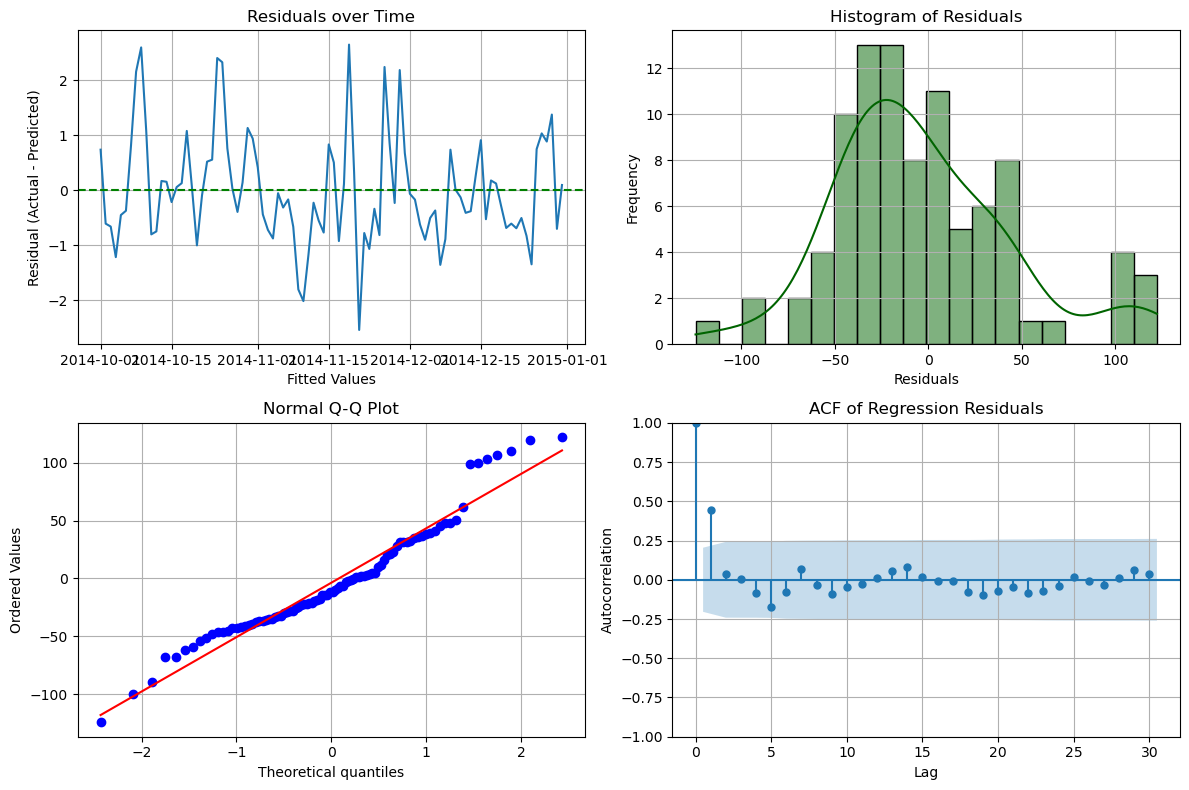

In [10]:
# Calculate residuals
results["Residual"] = results["pollution"] - results["Prediction"]
residuals = results["Residual"]

# Standardize Residuals
standardized_residuals = (residuals - residuals.mean()) / residuals.std()

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Standardized Residuals vs Fitted
axes[0, 0].plot(standardized_residuals)
axes[0, 0].axhline(y=0, color='green', linestyle='--')          
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residual (Actual - Predicted)')
axes[0, 0].set_title('Residuals over Time')
axes[0, 0].grid(True)

# 2. Histogram of Residuals
sns.histplot(residuals, bins=20, edgecolor='black', color='darkgreen', kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Histogram of Residuals')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True)

# 3. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Normal Q-Q Plot')
#axes[1, 0].set_ylim(-max_resid, max_resid)
axes[1, 0].grid(True)

# 4. Correlogram (ACF)
plot_acf(residuals, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('ACF of Regression Residuals')
axes[1, 1].set_xlabel('Lag')
axes[1, 1].set_ylabel('Autocorrelation')
axes[1, 1].grid(True)

# Show layout
plt.tight_layout()
plt.show()

In [11]:
# Display result
print(results[["pollution", "Prediction", "Error"]])

             pollution  Prediction      Error
date                                         
2014-10-01   82.541667   51.191784 -31.349883
2014-10-02   65.791667   98.376133  32.584466
2014-10-03  127.958333  163.092269  35.133936
2014-10-04   86.666667  148.206020  61.539353
2014-10-05   35.500000   60.671596  25.171596
...                ...         ...        ...
2014-12-27  238.666667  193.242881 -45.423786
2014-12-28  197.375000  158.985493 -38.389507
2014-12-29  159.000000   97.308887 -61.691113
2014-12-30   46.083333   83.187441  37.104108
2014-12-31   10.041667    9.227503  -0.814164

[92 rows x 3 columns]


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(results["pollution"], results["Prediction"])
rmse = np.sqrt(mean_squared_error(results["pollution"], results["Prediction"]))

print(f" MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

 MAE: 36.75
RMSE: 47.35


In [13]:
results

,dew,temp,press,snow,rain,pollution,dew_lag1,temp_lag1,press_lag1,snow_lag1,...,snow_lag6,rain_lag6,dew_lag7,temp_lag7,press_lag7,snow_lag7,rain_lag7,Prediction,Error,Residual
date,,,,,,,,,,,,,,,,,,,,,
2014-10-01,8.625000,11.708333,1016.416667,0.0,2.750000,82.541667,2.291667,12.458333,1026.041667,0.0,...,0.0,0.000000,15.583333,20.000000,1016.125000,0.0,0.833333,51.191784,-31.349883,31.349883
2014-10-02,11.333333,14.875000,1013.041667,0.0,0.000000,65.791667,8.625000,11.708333,1016.416667,0.0,...,0.0,0.041667,16.375000,18.416667,1016.291667,0.0,0.000000,98.376133,32.584466,-32.584466
2014-10-03,12.541667,14.958333,1017.375000,0.0,0.166667,127.958333,11.333333,14.875000,1013.041667,0.0,...,0.0,0.000000,16.416667,18.916667,1011.291667,0.0,0.041667,163.092269,35.133936,-35.133936
2014-10-04,13.416667,14.625000,1019.041667,0.0,1.875000,86.666667,12.541667,14.958333,1017.375000,0.0,...,0.0,0.000000,11.166667,18.458333,1015.875000,0.0,0.000000,148.206020,61.539353,-61.539353
2014-10-05,7.041667,15.125000,1024.291667,0.0,0.000000,35.500000,13.416667,14.625000,1019.041667,0.0,...,0.0,0.000000,13.958333,18.000000,1016.125000,0.0,0.000000,60.671596,25.171596,-25.171596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-27,-9.666667,-1.791667,1027.833333,0.0,0.000000,238.666667,-9.583333,-2.791667,1031.708333,0.0,...,0.0,0.000000,-18.583333,-1.958333,1030.208333,0.0,0.000000,193.242881,-45.423786,45.423786
2014-12-28,-10.791667,1.583333,1019.958333,0.0,0.000000,197.375000,-9.666667,-1.791667,1027.833333,0.0,...,0.0,0.000000,-18.541667,-1.708333,1027.541667,0.0,0.000000,158.985493,-38.389507,38.389507
2014-12-29,-12.333333,0.750000,1013.750000,0.0,0.000000,159.000000,-10.791667,1.583333,1019.958333,0.0,...,0.0,0.000000,-13.375000,-0.750000,1023.333333,0.0,0.000000,97.308887,-61.691113,61.691113


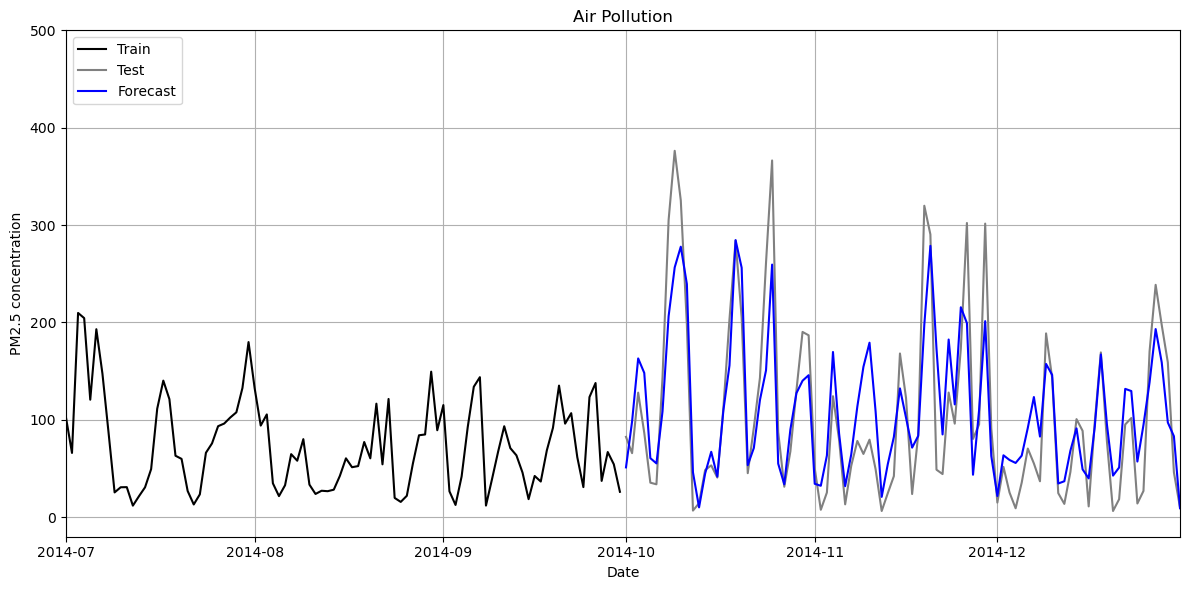

In [14]:
# Plot actual and fitted serie
plt.figure(figsize=(12, 6))                                      

plt.plot(train_df.index, train_df['pollution'], label='Train', color='black')       # Train
plt.plot(test_df.index, test_df['pollution'], label='Test', color='gray')           # Test
plt.plot(results.index, results['Prediction'], label='Forecast', color='blue')     # Forecast

plt.title('Air Pollution')                      
plt.xlabel('Date')                                        
plt.ylabel('PM2.5 concentration')  
plt.xlim(pd.to_datetime('2014-07-01'), pd.to_datetime('2014-12-31'))
#plt.ticklabel_format(style='plain', axis='y')  # Disable scientific notation on y-axis
plt.ylim(-20,500)
plt.grid(True)                                            
plt.legend(loc=2)                                             
plt.tight_layout()                                       
plt.show();